# Import packages

In [1]:
import pantarei as rei
import numpy as np
import matplotlib.pyplot as plt
from src.simulation_module import *

scheduler = rei.scheduler.ThreadScheduler(backend='process')

# Parameters setup

In [ ]:
###############
r_coll = 1.2
n_part = 2200

steps = 2e6


##########################
q = 0.2                 ##
r_part = r_coll*q       ##
box = 7                 ##
V = box**3              ##
n_coll = 2              ##
##########################



packing_fract_coll = pack_frac(r_coll,n_coll,V)
packing_fract_part = pack_frac(r_part,n_part,V)
rho_num = (n_coll+n_part)/V
print(f"Packing fraction colloids:  {packing_fract_coll:.2}")
print(f"Packing fraction particles: {packing_fract_part:.2}")
print(f"Density of number:          {rho_num:.3}")

Packing fraction colloids:  0.042
Packing fraction particles: 0.37
Density of number:          6.42


# Run the simulation

In [ ]:
clear_first = False
# clear_first = True              ## Toggle ##

task = rei.Task(simulation,clear_first=clear_first)
job = rei.Thread(task, scheduler=scheduler)

seeds = [10,11,12,13]
# seeds = [10,11,12,13]           # change r_coll 2.1->1.8, n_part 500->800 -- steps=2e6 (4h)
for seed in seeds:
    data = job(steps=steps,r_coll=r_coll,r_part=r_part,n_coll=n_coll,n_part=n_part,box=box,seed=seed)

In [3]:
data.columns()

['N',
 'T',
 '_dirname',
 '_path',
 'accept_ratio',
 'accept_ratio_coll',
 'box',
 'burnin',
 'effective time',
 'frames',
 'frames_dir',
 'initial parameters',
 'job_end',
 'job_fail',
 'job_queue',
 'job_start',
 'n_coll',
 'n_part',
 'packing_fract_coll',
 'packing_fract_part',
 'r_coll',
 'r_part',
 'seed',
 'steps',
 'tot_time',
 'trajectory',
 'trajectory_dir']

In [14]:

# seeds = [5,6,7,8] # change r_coll 2.1->1.8, n_part 500->800 -- 
steps=2e6 #(4h)
trajectory_directories = ['.trajectories/f8166d0a31dde9c0e747fe011e284a4e','.trajectories/43b58866aedb954eca4b5a876af6fb23','.trajectories/b3ffbfaba970f6015a2d7ca5b7740a3b']

# seeds = [5,6,7,8] # change r_coll 2.1->1.8, n_part 500->800 -- 
steps=2e6 #(4h)
trajectory_directories += ['.trajectories/9461c545564831f32fea3ecb582fe467','.trajectories/dc6e18b517f25f82b4e252b15bae56bd','.trajectories/142d58836678be9ebd47f86beaebfd5f','.trajectories/d3d9cdae7800c470ee2d481598d5699c']

# r_coll = 0.6, n_part = 10000 -- steps=4e6 (12h?)
steps=4e6
trajectory_directories = ['.trajectories/3fa87aed6a469838158e63fbcd0c2ecc','.trajectories/6f26527f4c707ba38d57f6acf34b61b9','.trajectories/8bf5cbb563176ea2424a78b12884ef29','.trajectories/01531a7f76a9bc2b6ef727ee6316614f']


blocks = [k*steps for k in range(len(trajectory_directories))]

trajectory = []
from src.traj_memmap import Trajectory_Memmap
for trajectory_dir in trajectory_directories:
    # trajectory_dir_memmap = './save_memmap/'+trajectory_dir
    trajectory_dir_memmap = trajectory_dir
    with Trajectory_Memmap(trajectory_dir=trajectory_dir_memmap,mode='r') as traj:
        print(traj.steps)
        for pos in traj:
            trajectory.append(pos)
    print(trajectory_dir_memmap + ' - DONE')

print(np.shape(trajectory))

[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 46000, 47000, 48000, 49000, 50000, 51000, 52000, 53000, 54000, 55000, 56000, 57000, 58000, 59000, 60000, 61000, 62000, 63000, 64000, 65000, 66000, 67000, 68000, 69000, 70000]
.trajectories/3fa87aed6a469838158e63fbcd0c2ecc - DONE
[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 46000, 47000, 48000, 49000, 50000, 51000, 52000, 53000, 54000, 55000, 56000, 57000, 58000, 59000, 60000, 61000, 62000, 63000, 64000, 65000, 66000, 6700

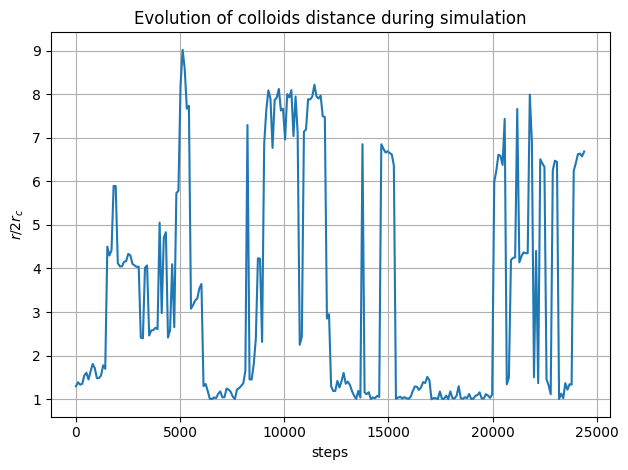

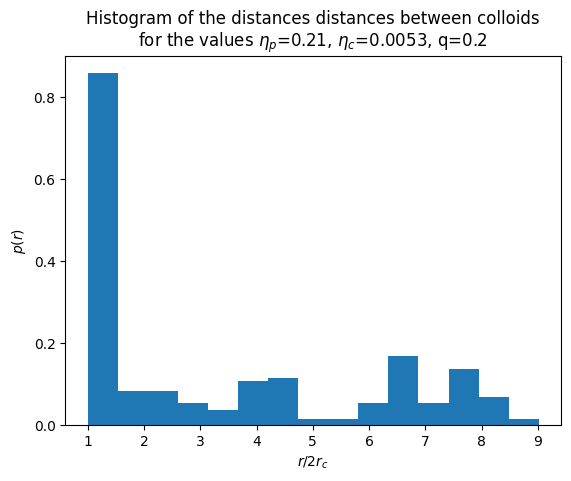

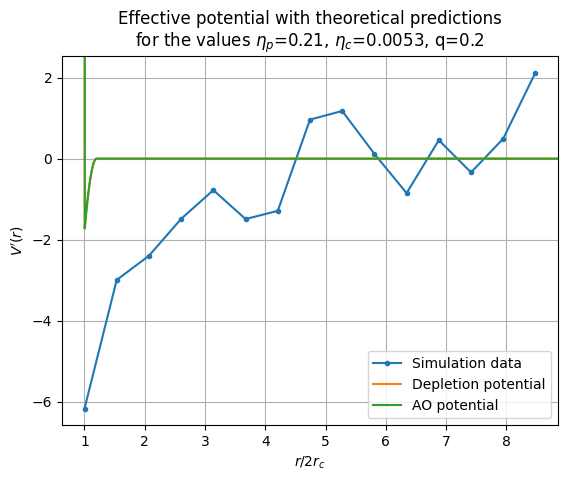

In [13]:
from src.simulation_module import *

##########################
r_coll = 0.6            ##
n_part = 10000          ##
                        ##
q = 0.2                 ##
r_part = r_coll*q       ##
box = 7                 ##
V = box**3              ##
n_coll = 2              ##
#########################################################
packing_fract_coll = pack_frac(r=r_coll,N=n_coll,V=V)  ##
packing_fract_part = pack_frac(r=r_part,N=n_part,V=V)  ##
#########################################################

# Cumulate the distances between colloids to plot the histogram
dist_colloids = []
# for pos in trajectory:
for i in range(0,len(trajectory),1):
    pos = trajectory[i]
    rij = pos[:,1] - pos[:,0]
    rij -= box * np.round(rij / box*2) # minimal image convention
    dist = np.linalg.norm(rij)
    dist_colloids.append(dist/2/r_coll) # normalize by 2*r_coll


# First take a look at the time evolution of the distances between colloids
blocks = None
plot_val_over_NMC(val=dist_colloids,x_multipl=100,blocks=blocks,ylabel=f"$r/2r_c$",title='Evolution of colloids distance during simulation')


# Now plot the histogram
plt.figure()
bins = 15                                                   # change n of bins here
d_bin = (max(dist_colloids) - min(dist_colloids))/bins
ttl = f"Histogram of the distances distances between colloids\nfor the values $\eta_p$={packing_fract_part:.2}, $\eta_c$={packing_fract_coll:.2}, q={q}"
pdr, dr, ax = plt.hist(dist_colloids,bins,density=True)
plt.title(ttl)
plt.ylabel(f"$p(r)$")
plt.xlabel(f"$r/2r_c$")



# Compute now the g(r)
# g(r) prop to p(r) / (4 pi r^2 dr)
gdr = [pdr[i]/(dr[i]**2 *4*np.pi*d_bin) for i in range(len(pdr))]
gdr /= np.mean(gdr[len(gdr)//4*3:]) # make the last points to be around 1

# Compute and plot the effective potential
Ueff = -np.log(gdr)
plt.figure()
plt.plot(dr[:-1],Ueff,'o-',markersize=3,label='Simulation data')


# Draw the 2 theoretical lines
r_coll_th = 0.5                     # the data was normalized by 2/r_coll
r_part_th = q*0.5                   # the data was normalized by 2/r_coll
x = np.linspace(0,box/r_coll,1000)
V_reduced = V / (2*r_coll)**3       # the data was normalized by 2/r_coll
density = (n_coll+n_part)/V_reduced

pot_full = [effective_potential(r,r_coll=r_coll_th,r_part=r_part_th,
                                N=(n_coll+n_part),V=V_reduced) for r in x]
pot_AO = [effective_potential(r,r_coll=r_coll_th,r_part=r_part_th,
                              N=(n_coll+n_part),V=V_reduced,which_pot='AO') for r in x]

plt.plot(x,pot_full,label='Depletion potential')
plt.plot(x,pot_AO,label='AO potential')

ddata = max(Ueff) - min(Ueff)
ddr = max(dr[:-1]) - min(dr[:-1])
plt.ylim([min(Ueff)-ddata/20,max(Ueff)+ddata/20])
plt.xlim([min(dr[:-1])-ddr/20,max(dr[:-1])+ddr/20])

plt.grid(True,which="both")
plt.legend()
ttl = f"Effective potential with theoretical predictions\nfor the values $\eta_p$={packing_fract_part:.2}, $\eta_c$={packing_fract_coll:.2}, q={q}"
plt.title(ttl)
plt.ylabel(f"$V'(r)$")
plt.xlabel(f"$r/2r_c$")

plt.show()